# **PART-A**

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
from google.colab import files
uploaded=files.upload()

Saving Photos data.zip to Photos data.zip


In [3]:
import zipfile
zip_name="Photos data.zip"

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content/asphalt_dataset")

In [4]:
print(os.listdir("/content/asphalt_dataset"))

['448']


In [5]:
print(os.listdir("/content/asphalt_dataset/448"))

['Cracks', 'NonCracks']


In [6]:
DATASET_PATH="/content/asphalt_dataset/448"
print(os.listdir(DATASET_PATH))

['Cracks', 'NonCracks']


In [7]:
image_extensions=('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
image_paths=[]
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_paths.append(os.path.join(root, file))
print("Total images found:", len(image_paths))

Total images found: 400


In [8]:
data=[]
for path in image_paths:
    folder_name=os.path.basename(os.path.dirname(path))
    if folder_name == "Cracks":
        label="Crack"
    else:
        label="Non-Crack"
    data.append({"image_path": path,"label": label})
image_df=pd.DataFrame(data)
print(image_df.head())

                                          image_path  label
0  /content/asphalt_dataset/448/Cracks/IMG_8533 r...  Crack
1  /content/asphalt_dataset/448/Cracks/IMG_201805...  Crack
2  /content/asphalt_dataset/448/Cracks/IMG_8488 r...  Crack
3  /content/asphalt_dataset/448/Cracks/IMG_8405 r...  Crack
4  /content/asphalt_dataset/448/Cracks/IMG_201805...  Crack


In [9]:
print("Class distribution:")
print(image_df["label"].value_counts())

Class distribution:
label
Crack        200
Non-Crack    200
Name: count, dtype: int64


In [10]:
print("\nClass distribution (%):")
print(image_df["label"].value_counts(normalize=True).mul(100).round(2))


Class distribution (%):
label
Crack        50.0
Non-Crack    50.0
Name: proportion, dtype: float64


In [11]:
sample_path=image_df.iloc[0]["image_path"]
image=cv2.imread(sample_path)
print("Image shape:", image.shape)

Image shape: (448, 448, 3)


In [12]:
dimensions=[]
for path in image_df["image_path"]:
    image=cv2.imread(path)
    if image is not None:
        height, width, channels=image.shape
        dimensions.append((height, width, channels))
dimension_df=pd.DataFrame(dimensions, columns=["Height", "Width", "Channels"])
print(dimension_df.head())

   Height  Width  Channels
0     448    448         3
1     448    448         3
2     448    448         3
3     448    448         3
4     448    448         3


In [13]:
print("\nUnique image dimensions:")
print(dimension_df.drop_duplicates().to_string(index=False))


Unique image dimensions:
 Height  Width  Channels
    448    448         3


In [14]:
print("\nDimension summary:")
print(dimension_df.describe())


Dimension summary:
       Height  Width  Channels
count   400.0  400.0     400.0
mean    448.0  448.0       3.0
std       0.0    0.0       0.0
min     448.0  448.0       3.0
25%     448.0  448.0       3.0
50%     448.0  448.0       3.0
75%     448.0  448.0       3.0
max     448.0  448.0       3.0


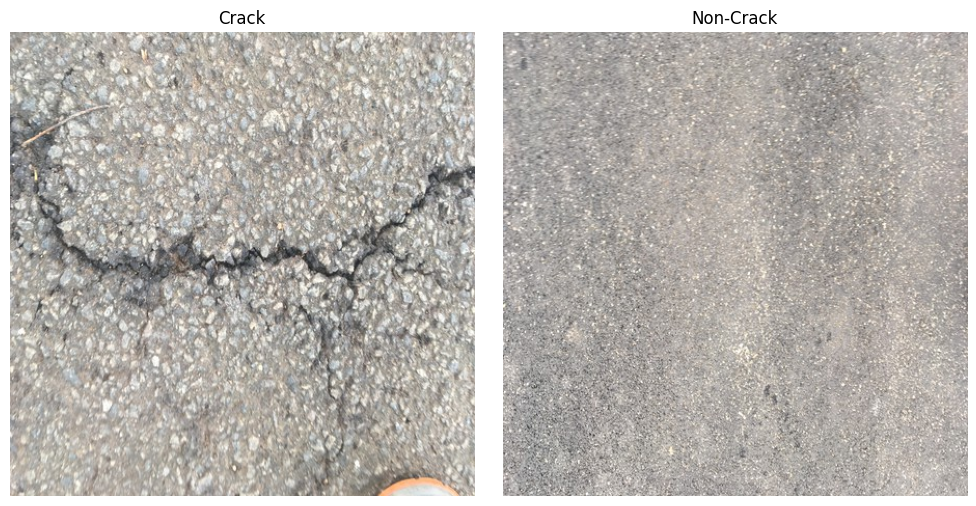

In [15]:
fig, axes=plt.subplots(1, 2, figsize=(10, 5))
for ax, class_name in zip(axes, ["Crack", "Non-Crack"]):
    sample=image_df[image_df["label"] == class_name].iloc[0]
    image=cv2.imread(sample["image_path"])
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [16]:
print("ASPHALT CRACK DATASET SUMMARY")
print("Total images:", len(image_df))
print("\nClass distribution:")
print(image_df["label"].value_counts())
print("\nUnique image dimensions:")
print(dimension_df.drop_duplicates().to_string(index=False))

ASPHALT CRACK DATASET SUMMARY
Total images: 400

Class distribution:
label
Crack        200
Non-Crack    200
Name: count, dtype: int64

Unique image dimensions:
 Height  Width  Channels
    448    448         3


In [17]:
IMG_SIZE=(250, 250)
# Test with one image
sample_image=cv2.imread(image_df.iloc[0]["image_path"])
resized=cv2.resize(sample_image, IMG_SIZE)
gray=cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

print("Original shape:", sample_image.shape)
print("Resized shape:", resized.shape)
print("Grayscale shape:", gray.shape)

Original shape: (448, 448, 3)
Resized shape: (250, 250, 3)
Grayscale shape: (250, 250)


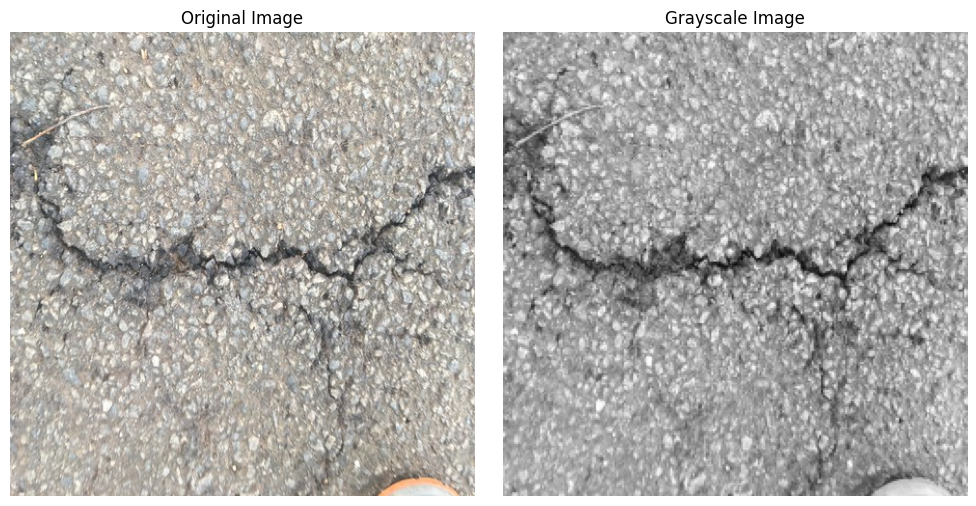

In [18]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sample_rgb=cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

plt.imshow(sample_rgb)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
mean_brightness=np.mean(gray)
contrast=np.std(gray)
dark_pixel_ratio=np.mean(gray < 50)
bright_pixel_ratio=np.mean(gray > 200)
median_intensity=np.median(gray)
min_intensity=np.min(gray)
max_intensity=np.max(gray)
intensity_range=max_intensity-min_intensity

print("Mean brightness:", mean_brightness)
print("Contrast:", contrast)
print("Dark-pixel ratio:", dark_pixel_ratio)
print("Bright-pixel ratio:", bright_pixel_ratio)
print("Median intensity:", median_intensity)
print("Minimum intensity:", min_intensity)
print("Maximum intensity:", max_intensity)
print("Intensity range:", intensity_range)

Mean brightness: 170.8392
Contrast: 31.347232594919763
Dark-pixel ratio: 0.000736
Bright-pixel ratio: 0.160832
Median intensity: 171.0
Minimum intensity: 32
Maximum intensity: 254
Intensity range: 222


In [20]:
image_features=[]
for _, row in image_df.iterrows():
    path=row["image_path"]
    label=row["label"]

    # Read image
    image=cv2.imread(path)

    # Resize
    resized=cv2.resize(image, IMG_SIZE)

    # Convert to grayscale
    gray=cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Intensity features
    mean_brightness=np.mean(gray)
    contrast=np.std(gray)
    dark_pixel_ratio=np.mean(gray < 50)
    bright_pixel_ratio=np.mean(gray > 200)
    median_intensity=np.median(gray)
    min_intensity=np.min(gray)
    max_intensity=np.max(gray)
    intensity_range=max_intensity-min_intensity
    image_features.append({"image_path": path, "label": label, "mean_brightness": mean_brightness, "contrast": contrast, "dark_pixel_ratio": dark_pixel_ratio,
    "bright_pixel_ratio": bright_pixel_ratio, "median_intensity": median_intensity, "min_intensity": min_intensity, "max_intensity": max_intensity,
    "intensity_range": intensity_range})

image_features_df=pd.DataFrame(image_features)
print(image_features_df.head())

                                          image_path  label  mean_brightness  \
0  /content/asphalt_dataset/448/Cracks/IMG_8533 r...  Crack       170.839200   
1  /content/asphalt_dataset/448/Cracks/IMG_201805...  Crack       110.192880   
2  /content/asphalt_dataset/448/Cracks/IMG_8488 r...  Crack       183.150768   
3  /content/asphalt_dataset/448/Cracks/IMG_8405 r...  Crack       127.431712   
4  /content/asphalt_dataset/448/Cracks/IMG_201805...  Crack       139.641744   

    contrast  dark_pixel_ratio  bright_pixel_ratio  median_intensity  \
0  31.347233          0.000736            0.160832             171.0   
1  40.019065          0.055424            0.007728             109.0   
2  22.989354          0.000000            0.231904             184.0   
3  19.802369          0.000000            0.001536             127.0   
4  35.996395          0.020576            0.035680             142.0   

   min_intensity  max_intensity  intensity_range  
0             32            254    

In [21]:
print("Feature table shape:", image_features_df.shape)

Feature table shape: (400, 10)


In [22]:
image_features_df.describe()

,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,median_intensity,min_intensity,max_intensity,intensity_range
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,150.750792,28.283406,0.005238,0.063150,150.710000,40.750000,252.300000,211.550000
std,17.758470,8.566112,0.013713,0.055922,17.823442,30.839669,3.428467,31.652206
min,110.192880,15.502622,0.000000,0.000704,109.000000,0.000000,227.000000,148.000000
25%,134.248520,20.398247,0.000000,0.015996,135.000000,13.000000,252.000000,182.750000
50%,152.604840,28.019803,0.000336,0.051944,153.000000,34.000000,253.000000,219.000000
75%,165.894776,34.236644,0.004384,0.089688,165.250000,69.250000,254.000000,240.000000
max,189.565280,57.457942,0.141680,0.283936,190.000000,105.000000,255.000000,255.000000


In [23]:
image_features_df.to_csv("/content/image_features_intensity.csv",index=False)
print("Feature table saved successfully.")

Feature table saved successfully.


In [24]:
# Apply Canny edge detection
edges=cv2.Canny(gray, 50, 150)
print("Edge image shape:", edges.shape)

Edge image shape: (250, 250)


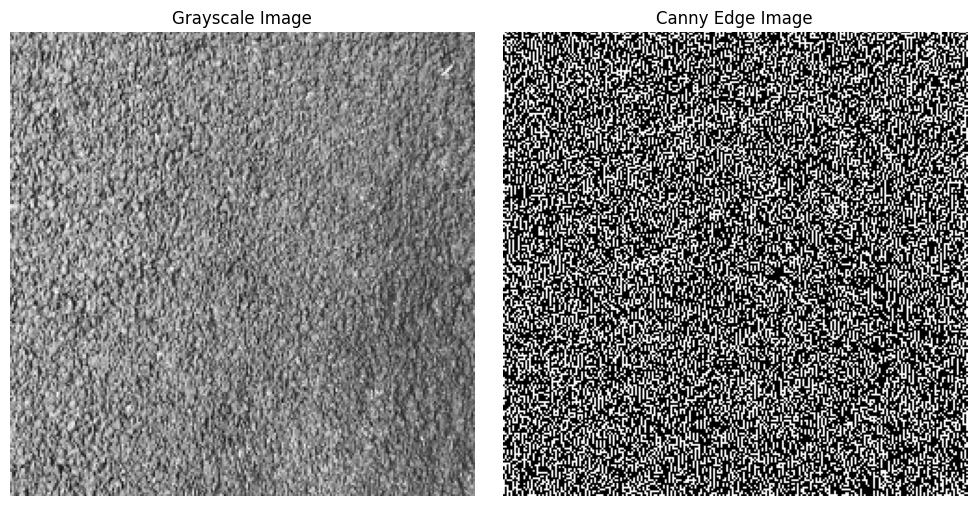

In [25]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Image")
plt.axis("off")
plt.tight_layout()
plt.show()

In [26]:
edge_count=np.sum(edges > 0)
print("Edge count:", edge_count)

Edge count: 23265


In [27]:
edge_density=np.mean(edges > 0)
print("Edge density:", edge_density)

Edge density: 0.37224


In [28]:
# Read image
image=cv2.imread(image_df.iloc[0]["image_path"])

# Resize
resized=cv2.resize(image, IMG_SIZE)

# Convert to grayscale
gray=cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

# Intensity features
mean_brightness=np.mean(gray)
contrast=np.std(gray)
dark_pixel_ratio=np.mean(gray < 50)
bright_pixel_ratio=np.mean(gray > 200)
median_intensity=np.median(gray)
min_intensity=np.min(gray)
max_intensity=np.max(gray)
intensity_range=max_intensity-min_intensity

# Canny edge detection
edges=cv2.Canny(gray, 50, 150)

# Edge features
edge_count=np.sum(edges > 0)
edge_density=np.mean(edges > 0)

print("Mean brightness:", mean_brightness)
print("Contrast:", contrast)
print("Dark-pixel ratio:", dark_pixel_ratio)
print("Bright-pixel ratio:", bright_pixel_ratio)
print("Median intensity:", median_intensity)
print("Minimum intensity:", min_intensity)
print("Maximum intensity:", max_intensity)
print("Intensity range:", intensity_range)
print("Edge count:", edge_count)
print("Edge density:", edge_density)

Mean brightness: 170.8392
Contrast: 31.347232594919763
Dark-pixel ratio: 0.000736
Bright-pixel ratio: 0.160832
Median intensity: 171.0
Minimum intensity: 32
Maximum intensity: 254
Intensity range: 222
Edge count: 22732
Edge density: 0.363712


In [29]:
edge_features=[]
for _, row in image_df.iterrows():
    path=row["image_path"]
    label=row["label"]

    # Read image
    image=cv2.imread(path)

    # Resize
    resized=cv2.resize(image, IMG_SIZE)

    # Grayscale
    gray=cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Canny edge detection
    edges=cv2.Canny(gray, 50, 150)

    # Edge features
    edge_count=np.sum(edges > 0)
    edge_density=np.mean(edges > 0)
    edge_features.append({"image_path": path, "label": label, "edge_count": edge_count, "edge_density": edge_density})

edge_features_df=pd.DataFrame(edge_features)
print(edge_features_df.head())

                                          image_path  label  edge_count  \
0  /content/asphalt_dataset/448/Cracks/IMG_8533 r...  Crack       22732   
1  /content/asphalt_dataset/448/Cracks/IMG_201805...  Crack       23500   
2  /content/asphalt_dataset/448/Cracks/IMG_8488 r...  Crack       23382   
3  /content/asphalt_dataset/448/Cracks/IMG_8405 r...  Crack       22863   
4  /content/asphalt_dataset/448/Cracks/IMG_201805...  Crack       23776   

   edge_density  
0      0.363712  
1      0.376000  
2      0.374112  
3      0.365808  
4      0.380416  


In [30]:
print("Edge feature table shape:", edge_features_df.shape)

Edge feature table shape: (400, 4)


In [31]:
final_image_features=pd.merge(image_features_df, edge_features_df, on=["image_path", "label"])
print(final_image_features.head())

                                          image_path  label  mean_brightness  \
0  /content/asphalt_dataset/448/Cracks/IMG_8533 r...  Crack       170.839200   
1  /content/asphalt_dataset/448/Cracks/IMG_201805...  Crack       110.192880   
2  /content/asphalt_dataset/448/Cracks/IMG_8488 r...  Crack       183.150768   
3  /content/asphalt_dataset/448/Cracks/IMG_8405 r...  Crack       127.431712   
4  /content/asphalt_dataset/448/Cracks/IMG_201805...  Crack       139.641744   

    contrast  dark_pixel_ratio  bright_pixel_ratio  median_intensity  \
0  31.347233          0.000736            0.160832             171.0   
1  40.019065          0.055424            0.007728             109.0   
2  22.989354          0.000000            0.231904             184.0   
3  19.802369          0.000000            0.001536             127.0   
4  35.996395          0.020576            0.035680             142.0   

   min_intensity  max_intensity  intensity_range  edge_count  edge_density  
0        

In [32]:
print("Final feature table shape:", final_image_features.shape)

Final feature table shape: (400, 12)


In [33]:
feature_columns=["mean_brightness","contrast", "dark_pixel_ratio", "bright_pixel_ratio", "median_intensity", "min_intensity", "max_intensity", "intensity_range",
"edge_count", "edge_density"]
X=final_image_features[feature_columns]
y=final_image_features["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 10)
y shape: (400,)


In [34]:
final_image_features.to_csv("/content/image_features.csv",index=False)
print("Final image feature table saved successfully.")

Final image feature table saved successfully.


In [35]:
print(pd.read_csv("/content/image_features.csv").head())

                                          image_path  label  mean_brightness  \
0  /content/asphalt_dataset/448/Cracks/IMG_8533 r...  Crack       170.839200   
1  /content/asphalt_dataset/448/Cracks/IMG_201805...  Crack       110.192880   
2  /content/asphalt_dataset/448/Cracks/IMG_8488 r...  Crack       183.150768   
3  /content/asphalt_dataset/448/Cracks/IMG_8405 r...  Crack       127.431712   
4  /content/asphalt_dataset/448/Cracks/IMG_201805...  Crack       139.641744   

    contrast  dark_pixel_ratio  bright_pixel_ratio  median_intensity  \
0  31.347233          0.000736            0.160832             171.0   
1  40.019065          0.055424            0.007728             109.0   
2  22.989354          0.000000            0.231904             184.0   
3  19.802369          0.000000            0.001536             127.0   
4  35.996395          0.020576            0.035680             142.0   

   min_intensity  max_intensity  intensity_range  edge_count  edge_density  
0        

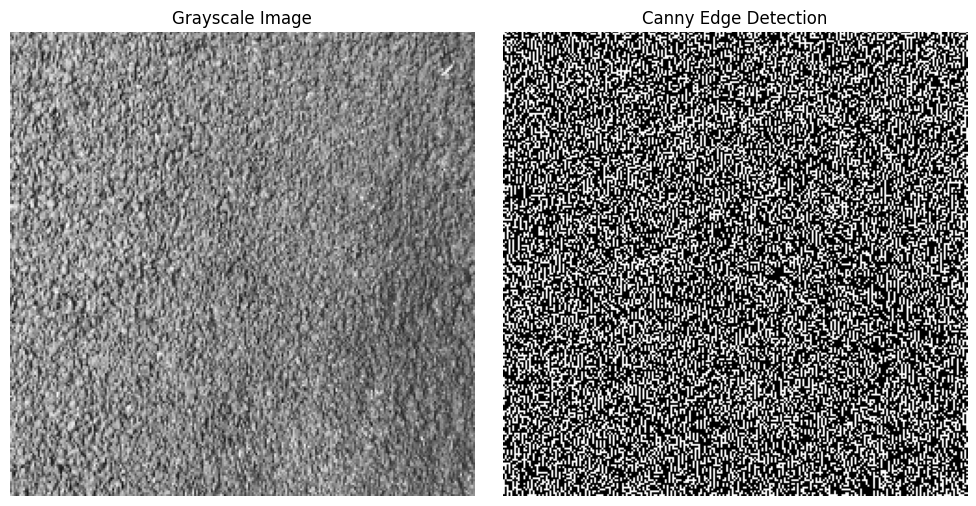

In [36]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.savefig("/content/canny_example.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
print(final_image_features.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   image_path          400 non-null    object 
 1   label               400 non-null    object 
 2   mean_brightness     400 non-null    float64
 3   contrast            400 non-null    float64
 4   dark_pixel_ratio    400 non-null    float64
 5   bright_pixel_ratio  400 non-null    float64
 6   median_intensity    400 non-null    float64
 7   min_intensity       400 non-null    uint8  
 8   max_intensity       400 non-null    uint8  
 9   intensity_range     400 non-null    uint8  
 10  edge_count          400 non-null    int64  
 11  edge_density        400 non-null    float64
dtypes: float64(6), int64(1), object(2), uint8(3)
memory usage: 29.4+ KB
None


In [38]:
print(final_image_features.describe())

       mean_brightness    contrast  dark_pixel_ratio  bright_pixel_ratio  \
count       400.000000  400.000000        400.000000          400.000000   
mean        150.750792   28.283406          0.005238            0.063150   
std          17.758470    8.566112          0.013713            0.055922   
min         110.192880   15.502622          0.000000            0.000704   
25%         134.248520   20.398247          0.000000            0.015996   
50%         152.604840   28.019803          0.000336            0.051944   
75%         165.894776   34.236644          0.004384            0.089688   
max         189.565280   57.457942          0.141680            0.283936   

       median_intensity  min_intensity  max_intensity  intensity_range  \
count        400.000000     400.000000     400.000000       400.000000   
mean         150.710000      40.750000     252.300000       211.550000   
std           17.823442      30.839669       3.428467        31.652206   
min          109.00

In [39]:
print(final_image_features[feature_columns].corr())

                    mean_brightness  contrast  dark_pixel_ratio  \
mean_brightness            1.000000 -0.407188         -0.404879   
contrast                  -0.407188  1.000000          0.570696   
dark_pixel_ratio          -0.404879  0.570696          1.000000   
bright_pixel_ratio         0.640991  0.252143         -0.041737   
median_intensity           0.993681 -0.372963         -0.377244   
min_intensity              0.750960 -0.680202         -0.406262   
max_intensity              0.126542  0.381866          0.089915   
intensity_range           -0.717975  0.704103          0.405572   
edge_count                -0.205977  0.737070          0.272943   
edge_density              -0.205977  0.737070          0.272943   

                    bright_pixel_ratio  median_intensity  min_intensity  \
mean_brightness               0.640991          0.993681       0.750960   
contrast                      0.252143         -0.372963      -0.680202   
dark_pixel_ratio             -0.04173

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)
import time

In [41]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 320
Testing samples: 80


In [42]:
models={"Logistic Regression": Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=1000, random_state=42))]),
          "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),"SVM": Pipeline([("scaler", StandardScaler()),("model", SVC(kernel="rbf",
          random_state=42))])}

In [43]:
results=[]
predictions={}

for name, model in models.items():

    # Training time
    start_train=time.time()
    model.fit(X_train, y_train)
    training_time=time.time()-start_train

    # Prediction time
    start_predict=time.time()
    y_pred=model.predict(X_test)
    prediction_time=time.time()-start_predict
    predictions[name]=y_pred

    # Metrics
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred, pos_label="Crack")
    recall=recall_score(y_test, y_pred,pos_label="Crack")
    f1=f1_score(y_test, y_pred, pos_label="Crack")

    results.append({"Model": name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1 Score": f1, "Training Time (s)": training_time,
    "Prediction Time (s)": prediction_time})
results_df=pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9250,0.886364,0.975,0.928571,0.097669,0.007664
1,Random Forest,0.9750,0.952381,1.000,0.975610,0.394399,0.016449
2,SVM,0.9625,0.951220,0.975,0.962963,0.012098,0.004075


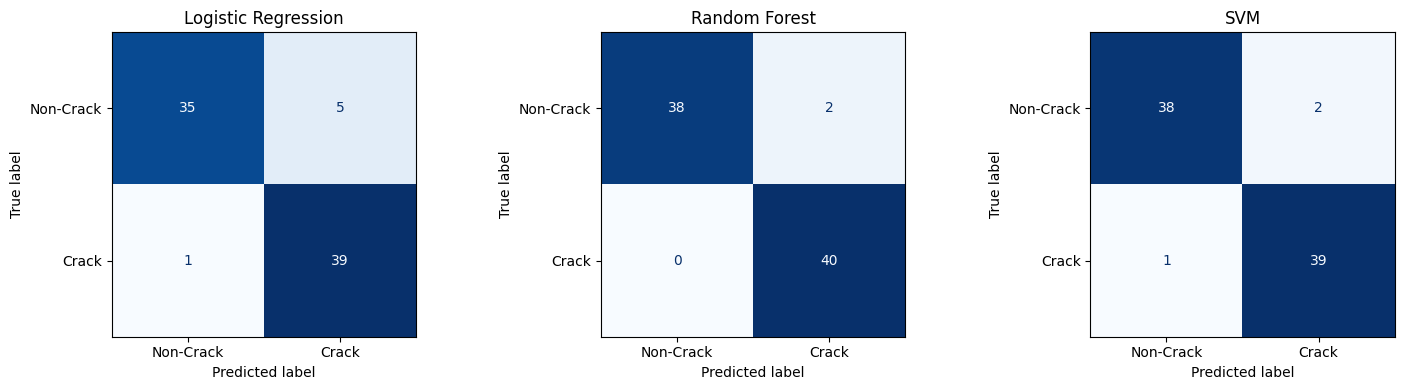

In [44]:
fig, axes=plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm=confusion_matrix(y_test, y_pred, labels=["Non-Crack", "Crack"])
    disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Crack", "Crack"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [45]:
results_df.to_csv("/content/image_model_results.csv",index=False)
print("Results saved successfully.")

Results saved successfully.


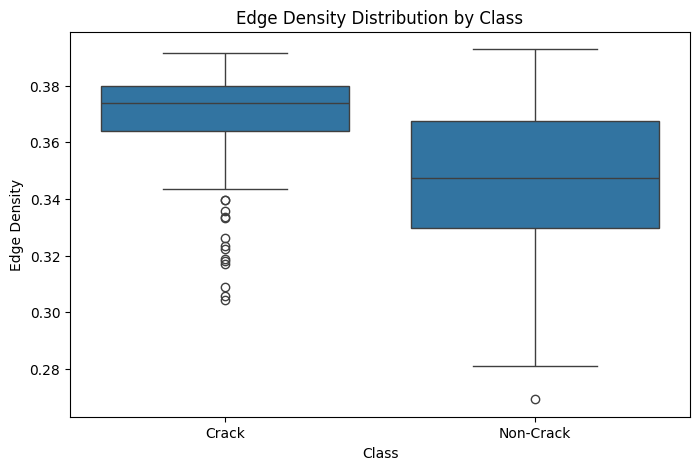

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.boxplot(data=final_image_features, x="label", y="edge_density")
plt.title("Edge Density Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Edge Density")

plt.savefig("/content/edge_density_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# **PART-C**

In [47]:
multi_edge_features=[]

for _, row in image_df.iterrows():
    path=row["image_path"]
    label=row["label"]
    image=cv2.imread(path)

    # Resize
    resized=cv2.resize(image, IMG_SIZE)

    # Grayscale
    gray=cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Different Canny thresholds
    edges_1=cv2.Canny(gray, 30, 100)
    edges_2=cv2.Canny(gray, 50, 150)
    edges_3=cv2.Canny(gray, 70, 200)

    # Edge densities
    density_1=np.mean(edges_1 > 0)
    density_2=np.mean(edges_2 > 0)
    density_3=np.mean(edges_3 > 0)

    # Edge counts
    count_1=np.sum(edges_1 > 0)
    count_2=np.sum(edges_2 > 0)
    count_3=np.sum(edges_3 > 0)

    multi_edge_features.append({"image_path": path, "label": label, "edge_density_30_100": density_1, "edge_density_50_150": density_2, "edge_density_70_200": density_3,
    "edge_count_30_100": count_1, "edge_count_50_150": count_2, "edge_count_70_200": count_3})

multi_edge_df=pd.DataFrame(multi_edge_features)
multi_edge_df.head()

,image_path,label,edge_density_30_100,edge_density_50_150,edge_density_70_200,edge_count_30_100,edge_count_50_150,edge_count_70_200
0,/content/asphalt_dataset/448/Cracks/IMG_8533 r...,Crack,0.372608,0.363712,0.347424,23288,22732,21714
1,/content/asphalt_dataset/448/Cracks/IMG_201805...,Crack,0.377728,0.376000,0.373392,23608,23500,23337
2,/content/asphalt_dataset/448/Cracks/IMG_8488 r...,Crack,0.381696,0.374112,0.358544,23856,23382,22409
3,/content/asphalt_dataset/448/Cracks/IMG_8405 r...,Crack,0.379840,0.365808,0.333568,23740,22863,20848
4,/content/asphalt_dataset/448/Cracks/IMG_201805...,Crack,0.384304,0.380416,0.373424,24019,23776,23339


In [48]:
improved_features_df=pd.merge(image_features_df, multi_edge_df, on=["image_path", "label"])
print("Improved feature shape:", improved_features_df.shape)

Improved feature shape: (400, 16)


In [49]:
improved_feature_columns=["mean_brightness", "contrast", "dark_pixel_ratio", "bright_pixel_ratio", "median_intensity", "min_intensity", "max_intensity",
"intensity_range", "edge_density_30_100", "edge_density_50_150", "edge_density_70_200", "edge_count_30_100", "edge_count_50_150", "edge_count_70_200"]

X_improved=improved_features_df[improved_feature_columns]
y_improved=improved_features_df["label"]
print("X shape:", X_improved.shape)
print("y shape:", y_improved.shape)

X shape: (400, 14)
y shape: (400,)


In [50]:
X_train_imp, X_test_imp, y_train_imp, y_test_imp=train_test_split(X_improved,y_improved,test_size=0.2, random_state=42, stratify=y_improved)

In [51]:
print("Improved feature shape:", improved_features_df.shape)

Improved feature shape: (400, 16)


In [52]:
improved_models={"Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=42))]),
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),
    "SVM": Pipeline([("scaler", StandardScaler()),("model", SVC(kernel="rbf", random_state=42))])}

In [53]:
improved_results=[]
improved_predictions={}

for name, model in improved_models.items():

    # Training time
    start_train=time.time()
    model.fit(X_train_imp, y_train_imp)
    training_time=time.time()-start_train

    # Prediction time
    start_predict=time.time()
    y_pred=model.predict(X_test_imp)
    prediction_time=time.time()-start_predict
    improved_predictions[name]=y_pred

    # Metrics
    accuracy=accuracy_score(y_test_imp, y_pred)
    precision=precision_score(y_test_imp, y_pred, pos_label="Crack")
    recall=recall_score(y_test_imp, y_pred, pos_label="Crack")
    f1=f1_score(y_test_imp, y_pred, pos_label="Crack")
    improved_results.append({"Model": name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1 Score": f1, "Training Time (s)": training_time,
    "Prediction Time (s)": prediction_time})

improved_results_df=pd.DataFrame(improved_results)
improved_results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9250,0.886364,0.975,0.928571,0.013623,0.002719
1,Random Forest,0.9625,0.930233,1.000,0.963855,0.285603,0.009500
2,SVM,0.9250,0.886364,0.975,0.928571,0.007203,0.002745


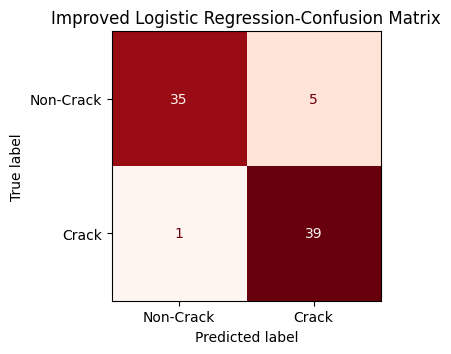

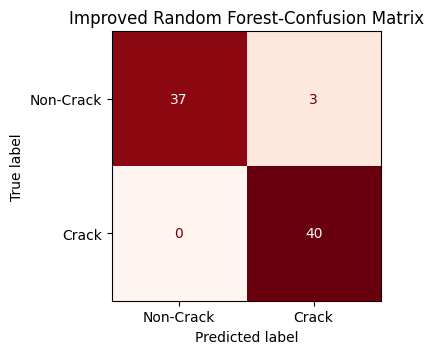

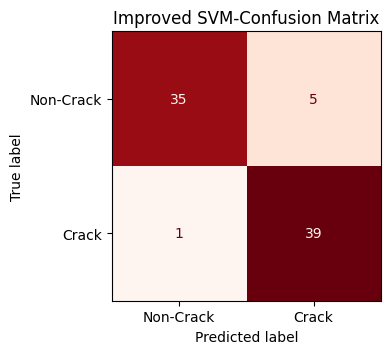

In [54]:
for name, y_pred in improved_predictions.items():

    cm=confusion_matrix(y_test_imp, y_pred, labels=["Non-Crack", "Crack"])
    disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Crack", "Crack"])
    fig, ax=plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, cmap="Reds",colorbar=False)
    ax.set_title(f"Improved {name}-Confusion Matrix")
    plt.tight_layout()
    filename=("improved_"+name.lower().replace(" ", "_")+"_confusion_matrix.png")
    plt.savefig(f"/content/improved", dpi=300, bbox_inches="tight")
    plt.show()

In [55]:
baseline_comparison=results_df[["Model", "Accuracy", "Precision", "Recall", "F1 Score"]].copy()
baseline_comparison=baseline_comparison.rename(columns={"Accuracy": "Baseline Accuracy", "Precision": "Baseline Precision", "Recall": "Baseline Recall",
"F1 Score": "Baseline F1"})

improved_comparison=improved_results_df[["Model", "Accuracy", "Precision", "Recall", "F1 Score"]].copy()
improved_comparison=improved_comparison.rename(columns={"Accuracy": "Improved Accuracy", "Precision": "Improved Precision", "Recall": "Improved Recall",
"F1 Score": "Improved F1"})
comparison_df=pd.merge(baseline_comparison, improved_comparison, on="Model")
comparison_df

,Model,Baseline Accuracy,Baseline Precision,Baseline Recall,Baseline F1,Improved Accuracy,Improved Precision,Improved Recall,Improved F1
0,Logistic Regression,0.9250,0.886364,0.975,0.928571,0.9250,0.886364,0.975,0.928571
1,Random Forest,0.9750,0.952381,1.000,0.975610,0.9625,0.930233,1.000,0.963855
2,SVM,0.9625,0.951220,0.975,0.962963,0.9250,0.886364,0.975,0.928571


In [56]:
import shutil

RESULTS_PATH="/content/final_results"
os.makedirs(RESULTS_PATH, exist_ok=True)

# 1. Original intensity features
image_features_df.to_csv(f"{RESULTS_PATH}/image_features_intensity.csv", index=False)

# 2. Original 10-feature dataset
final_image_features.to_csv(f"{RESULTS_PATH}/image_features_baseline.csv", index=False)

# 3. Improved 16-feature dataset
improved_features_df.to_csv(f"{RESULTS_PATH}/image_features_improved.csv", index=False)

# 4. Baseline model results
results_df.to_csv(f"{RESULTS_PATH}/baseline_model_results.csv", index=False)

# 5. Improved model results
improved_results_df.to_csv(f"{RESULTS_PATH}/improved_model_results.csv", index=False)

# 6. Baseline vs improved comparison
comparison_df.to_csv(f"{RESULTS_PATH}/model_comparison.csv",index=False)

# 7. Copy Canny visualization
if os.path.exists("/content/canny_example.png"):
    shutil.copy("/content/canny_example.png", f"{RESULTS_PATH}/canny_example.png")

# 8. Copy edge density visualization
if os.path.exists("/content/edge_density_distribution.png"):
    shutil.copy("/content/edge_density_distribution.png", f"{RESULTS_PATH}/edge_density_distribution.png")

# 9. Copy confusion matrices
for file in os.listdir("/content"):
    if "confusion_matrix.png" in file:
        shutil.copy(f"/content/{file}", f"{RESULTS_PATH}/{file}")

print("All final results saved successfully!")

All final results saved successfully!


In [57]:
print("FINAL MODEL COMPARISON")
display(comparison_df)

FINAL MODEL COMPARISON


,Model,Baseline Accuracy,Baseline Precision,Baseline Recall,Baseline F1,Improved Accuracy,Improved Precision,Improved Recall,Improved F1
0,Logistic Regression,0.9250,0.886364,0.975,0.928571,0.9250,0.886364,0.975,0.928571
1,Random Forest,0.9750,0.952381,1.000,0.975610,0.9625,0.930233,1.000,0.963855
2,SVM,0.9625,0.951220,0.975,0.962963,0.9250,0.886364,0.975,0.928571


# **PART-B**

In [58]:
df=pd.read_csv("emails.csv")

In [59]:
print(df.shape)
print(df.head())
print(df.columns)
print(df.info())
df.isnull().sum()
print("Duplicate rows:", df.duplicated().sum())

(5172, 3002)
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]
Index(['Email No.', 'the', 'to', 'ect', 'and', 'f

In [60]:
print(df.columns.tolist())

['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', 'net', 'followin

In [61]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64

Duplicate rows: 0


In [62]:
X_text=df.drop(columns=["Email No.", "Prediction"])
y_text=df["Prediction"]

print("Feature matrix shape:", X_text.shape)
print("Target shape:", y_text.shape)

print("\nTarget distribution:")
print(y_text.value_counts())

Feature matrix shape: (5172, 3000)
Target shape: (5172,)

Target distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64


In [63]:
print("First 5 feature rows:")
display(X_text.head())

print("\nFeature data type:")
print(X_text.dtypes.value_counts())

First 5 feature rows:


,the,to,ect,and,for,of,a,you,hou,in,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
0,0,0,1,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,13,24,6,6,2,102,1,27,18,...,0,0,0,0,0,0,0,0,1,0
2,0,0,1,0,0,0,8,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,5,22,0,5,1,51,2,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,6,17,1,5,2,57,0,9,3,...,0,0,0,0,0,0,0,0,1,0



Feature data type:
int64    3000
Name: count, dtype: int64


In [64]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_text, y_test_text=train_test_split(X_text, y_text, test_size=0.2, random_state=42, stratify=y_text)

print("Training samples:", X_train_text.shape[0])
print("Testing samples:", X_test_text.shape[0])

print("Training features:", X_train_text.shape[1])
print("Testing features:", X_test_text.shape[1])

Training samples: 4137
Testing samples: 1035
Training features: 3000
Testing features: 3000


In [65]:
print("Training class distribution:")
print(y_train_text.value_counts())

print("\nTesting class distribution:")
print(y_test_text.value_counts())

Training class distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing class distribution:
Prediction
0    735
1    300
Name: count, dtype: int64


In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X_text, y_text, test_size=0.20, random_state=42, stratify=y_text)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (4137, 3000)
Testing feature shape: (1035, 3000)
Training target shape: (4137,)
Testing target shape: (1035,)


In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Logistic Regression
lr_model=LogisticRegression(max_iter=1000, random_state=42)

# Random Forest
rf_model=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# SVM
svm_model=SVC(kernel='linear', random_state=42)

# Train the models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


In [69]:
print("Training class distribution:")
print(y_train_text.value_counts())

print("\nTesting class distribution:")
print(y_test_text.value_counts())

Training class distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing class distribution:
Prediction
0    735
1    300
Name: count, dtype: int64


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_text, y_text, test_size=0.20, random_state=42,stratify=y_text)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (4137, 3000)
Testing feature shape: (1035, 3000)
Training target shape: (4137,)
Testing target shape: (1035,)


In [73]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing class distribution:
Prediction
0    735
1    300
Name: count, dtype: int64


In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

lr_model = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
svm_model = SVC(kernel="linear", random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

results_B = []

models_B = {"Logistic Regression": y_pred_lr, "Random Forest": y_pred_rf, "SVM": y_pred_svm}

for model_name, y_pred in models_B.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    results_B.append({"Model": model_name,"Accuracy": accuracy,"Precision": precision,"Recall": recall,"F1 Score": f1})
results_B_df = pd.DataFrame(results_B)
print(results_B_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.982609   0.957792  0.983333  0.970395
1        Random Forest  0.964251   0.933993  0.943333  0.938640
2                  SVM  0.967150   0.937500  0.950000  0.943709


In [76]:
results_B_df.to_csv("Part_B_metrics.csv", index=False)
print("Part B metrics saved as Part_B_metrics.csv")

Part B metrics saved as Part_B_metrics.csv


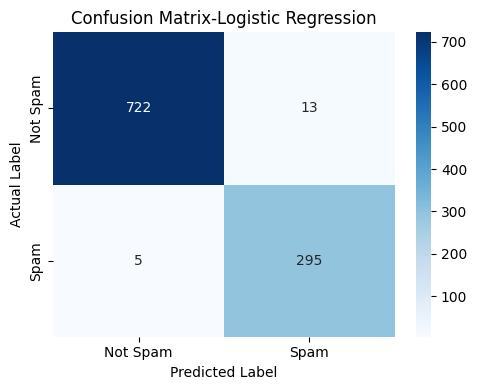

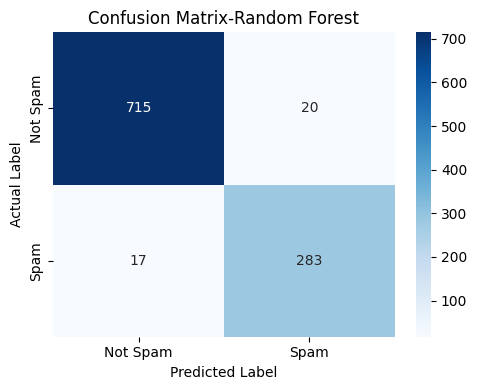

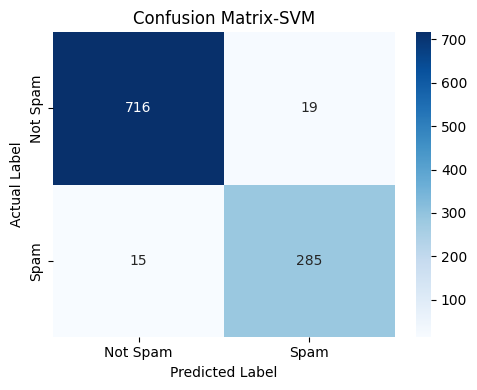

In [77]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

predictions={"Logistic Regression": y_pred_lr, "Random Forest": y_pred_rf, "SVM": y_pred_svm}

for model_name, y_pred in predictions.items():
    cm=confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Spam", "Spam"], yticklabels=["Not Spam", "Spam"])

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(f"Confusion Matrix-{model_name}")
    plt.tight_layout()
    plt.show()

In [78]:
import time
import pandas as pd

timing_results=[]

models_timing={"Logistic Regression": LogisticRegression(max_iter=1000, random_state=42), "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42,
n_jobs=-1), "SVM": SVC(kernel="linear", random_state=42)}

for model_name, model in models_timing.items():

    # Training time
    start_train=time.perf_counter()
    model.fit(X_train, y_train)
    end_train=time.perf_counter()
    training_time=end_train-start_train

    # Prediction time
    start_pred=time.perf_counter()
    y_pred=model.predict(X_test)
    end_pred=time.perf_counter()
    prediction_time=end_pred-start_pred

    timing_results.append({"Model": model_name, "Training Time (s)": training_time, "Prediction Time (s)": prediction_time})

timing_df=pd.DataFrame(timing_results)
print(timing_df.round(6))

                 Model  Training Time (s)  Prediction Time (s)
0  Logistic Regression          18.974665             0.048991
1        Random Forest           2.124834             0.067819
2                  SVM           8.368658             0.529314


In [79]:
timing_df.to_csv("Part_B_timing.csv", index=False)
print("Part B timing results saved.")

Part B timing results saved.


In [81]:
final_B_results=results_B_df.merge(timing_df, on="Model")
print(final_B_results.round(6))

                 Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression  0.982609   0.957792  0.983333  0.970395   
1        Random Forest  0.964251   0.933993  0.943333  0.938640   
2                  SVM  0.967150   0.937500  0.950000  0.943709   

   Training Time (s)  Prediction Time (s)  
0          18.974665             0.048991  
1           2.124834             0.067819  
2           8.368658             0.529314  


In [82]:
final_B_results.to_csv("Part_B_Final_Results.csv", index=False)
print("Final Part B results saved as Part_B_Final_Results.csv")

Final Part B results saved as Part_B_Final_Results.csv


In [83]:
from sklearn.metrics import classification_report

for model_name, y_pred in predictions.items():
    print(model_name)
    print(classification_report(y_test, y_pred, target_names=["Not Spam", "Spam"], digits=4))

Logistic Regression
              precision    recall  f1-score   support

    Not Spam     0.9931    0.9823    0.9877       735
        Spam     0.9578    0.9833    0.9704       300

    accuracy                         0.9826      1035
   macro avg     0.9755    0.9828    0.9790      1035
weighted avg     0.9829    0.9826    0.9827      1035

Random Forest
              precision    recall  f1-score   support

    Not Spam     0.9768    0.9728    0.9748       735
        Spam     0.9340    0.9433    0.9386       300

    accuracy                         0.9643      1035
   macro avg     0.9554    0.9581    0.9567      1035
weighted avg     0.9644    0.9643    0.9643      1035

SVM
              precision    recall  f1-score   support

    Not Spam     0.9795    0.9741    0.9768       735
        Spam     0.9375    0.9500    0.9437       300

    accuracy                         0.9671      1035
   macro avg     0.9585    0.9621    0.9603      1035
weighted avg     0.9673    0.9671   

In [84]:
report_text=""
for model_name, y_pred in predictions.items():
    report_text+="="*60+"\n"
    report_text+=model_name+"\n"
    report_text+="="*60+"\n"
    report_text+=classification_report(y_test, y_pred, target_names=["Not Spam", "Spam"], digits=4)
    report_text+="\n"

with open("Part_B_Classification_Reports.txt", "w") as f:
    f.write(report_text)

print("Classification reports saved.")

Classification reports saved.


In [85]:
predictions_df=pd.DataFrame({"Actual": y_test.values, "Logistic Regression": y_pred_lr, "Random Forest": y_pred_rf, "SVM": y_pred_svm})
predictions_df.to_csv("Part_B_Predictions.csv", index=False)
print("Predictions saved as Part_B_Predictions.csv")
print(predictions_df.head())

Predictions saved as Part_B_Predictions.csv
   Actual  Logistic Regression  Random Forest  SVM
0       0                    0              0    0
1       0                    0              0    0
2       0                    0              0    0
3       0                    0              0    0
4       0                    1              1    1


In [86]:
final_B_results=final_B_results.round(6)
final_B_results.to_csv("Part_B_Final_Results.csv", index=False)

print("FINAL PART B RESULTS")
print(final_B_results)
print("\nSaved as: Part_B_Final_Results.csv")

FINAL PART B RESULTS
                 Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression  0.982609   0.957792  0.983333  0.970395   
1        Random Forest  0.964251   0.933993  0.943333  0.938640   
2                  SVM  0.967150   0.937500  0.950000  0.943709   

   Training Time (s)  Prediction Time (s)  
0          18.974665             0.048991  
1           2.124834             0.067819  
2           8.368658             0.529314  

Saved as: Part_B_Final_Results.csv
